# ESTIMATION OF $\pi$ - USING MONTE CARLO METHOD

---

## 1. Random Darts:
---

Let us imagine a square of side length 2 units centered at origin (0,0). Inside  let us inscribe a circle of radius 1 unit touching all four sides.

Area of the square is given by $(2)^2$= $4$

And  the area of the circle is given by $\pi r^2$= $\pi$

If we throw darts completely randomly across the square, the fraction that landinside the circle should equal the ratio of their areas:

$\frac{\text{darts inside circle}}{\text{total darts}} = \frac{\text{area of circle}}{\text{area of square}} = \frac{\pi}{4}$

Rearrange: $\pi = 4 \times {\frac{\text{darts inside}}{\text{ total darts}}}$.



Each dart is a point (x, y) with both coordinates chosen uniformly from [-1, +1]. It lands inside the circle if $x^2+y^2 \leq 1 $. From here if we know total darts thrown and how many fell inside we can estimate $\pi$.

This is Monte Carlo integration in estimating an area by sampling points randomly and counting how many fall inside the region of interest.

## 2. Basic Algorithm:
---

We build the most basic foundational block of the algorithm that is choosing two completely random points for x and y respectively, and we check if the point (x,y) lies on the circle. To check the location of the point, we find the distance of the point $\sqrt (x^2+y^2) \leq R$ , where R is the radius of the circle. If the point is inside the circle we update our counter, and after we have checked sufficient number of points we calculate the probability of the point being inside the cirle and multiply it with 4 from the eqn. and we get the estimated value of $\pi$


In [10]:
import random
import matplotlib.pyplot as plt
import math
x=y=in_c=0

n=1000

for i in range(n):
    x= random.uniform(-1,1)
    y= random.uniform(-1,1)
    dist= ((x*x)+(y*y))**0.5
    if dist<=1:
        in_c+=1

pi= 4*(in_c/n)
print(f"The estimated value after checking {n} points is {pi}" )

The estimated value after checking 1000 points is 3.12


**RESULT:**

We check the presence of all the points (or the darts that we have thrown) inside the circle, and the total number of points and we can estimate the value of $\pi$ correct to around to one decimal place. Thus showing that if we have enough observations (or honestly the computation power of enough observation) we can calculate $\pi$ upto our required number of terms.

## 3. Plotting of 100,000 Darts: Emergence of the circle
---

We throw 100,000 darts at the square. Each dart that lands inside the circle is colored green. Outside the circle is colored red. A black circle marks the boundary. We try to estimate $\pi$ again but this time with more darts thrown.

The estimated value of pi with 100000 darts is: 3.14496


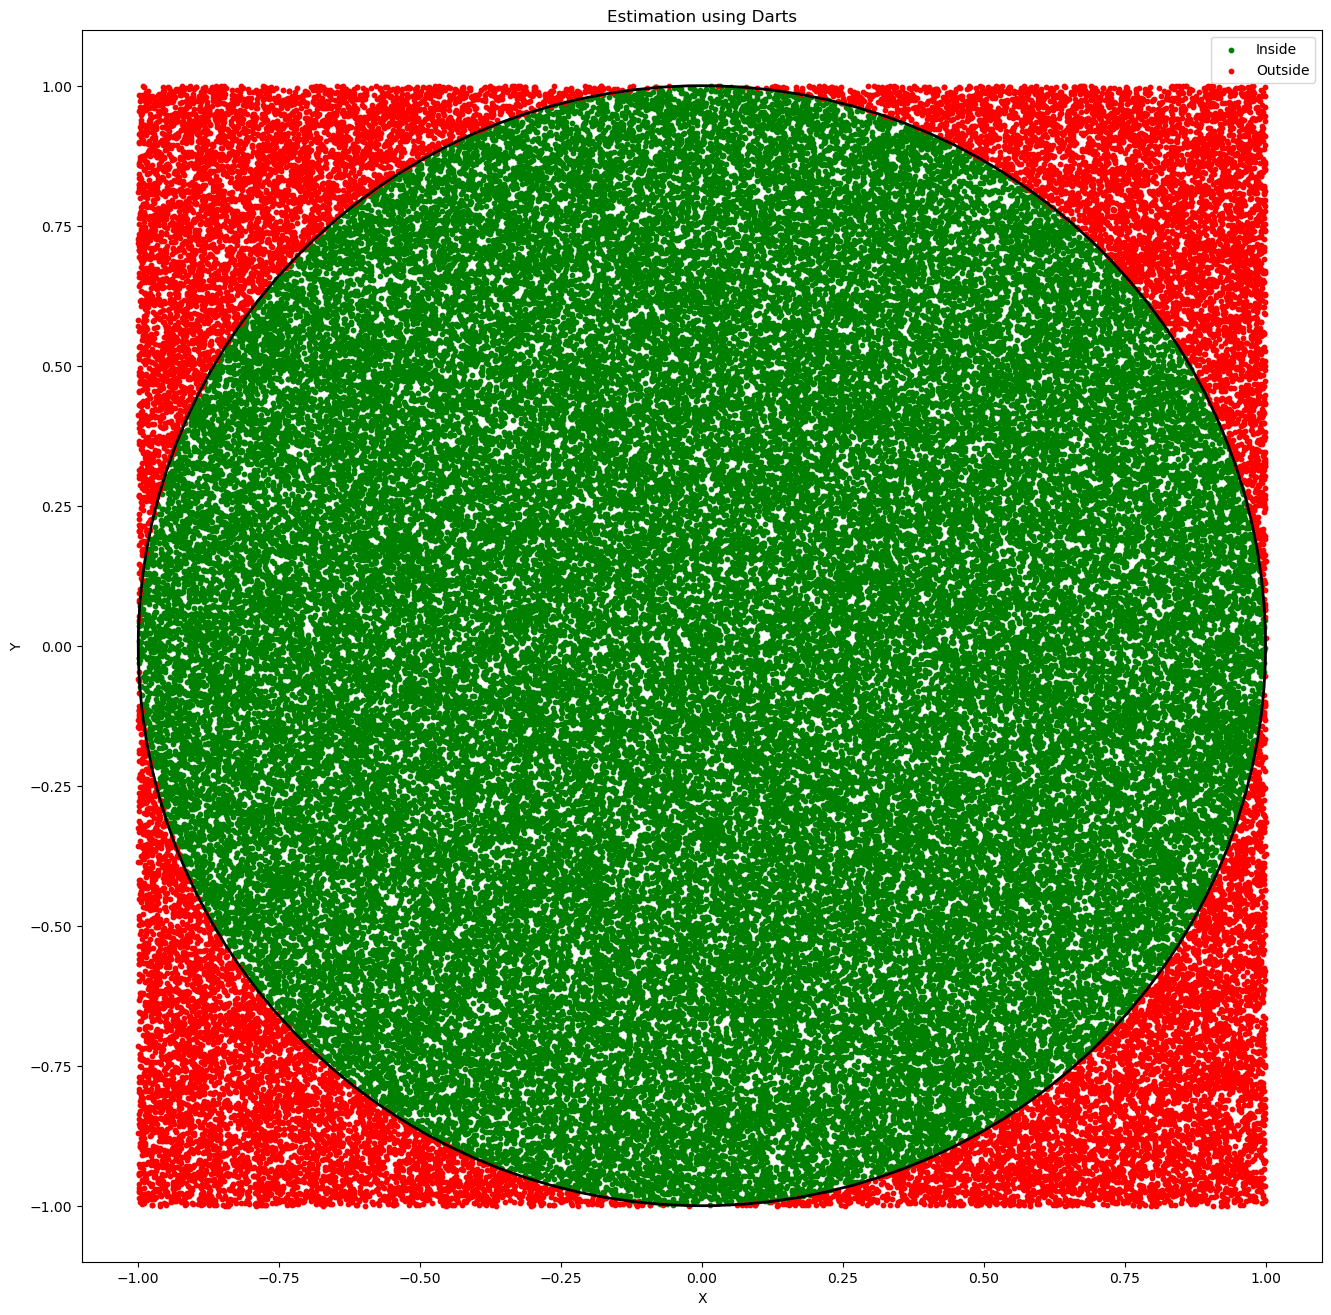

In [15]:
import random
import matplotlib.pyplot as plt
import math
x=y=0

n=100000
in_x,in_y=[],[]
out_x,out_y=[],[]

for i in range(n):
    x= random.uniform(-1,1)
    y= random.uniform(-1,1)
    dist= ((x*x)+(y*y))**0.5
    if dist<=1:
        in_x.append(x)
        in_y.append(y)
    else:
        out_x.append(x)
        out_y.append(y)

pi_est= 4*len(in_x)/n


print(f"The estimated value of pi with {n} darts is: {pi_est}")

plt.figure(figsize=(16,16))
plt.scatter(in_x,in_y, color='green', s=10, label='Inside')
plt.scatter(out_x,out_y, color='red', s=10, label='Outside')
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
plt.gca().add_patch(circle)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Estimation using Darts')
plt.legend()
plt.show()

**RESULT**:

At a glance, the circle emerges from the density of green points. The boundary is created by the location of the variety of points. The estimate improves with more darts, as we have seen in the previous run with 1000 darts vs now with 100,000 darts. But it's slow and noisy. With 100,000 darts, we typically get 2-3 correct decimal places, even after going from $10^3$ to to $10^5$ we get increase of only 1 correct decimal place. 

## 4. Convergence of the estimate: 
---

Now we try to figure out if the values of estimated $\pi$ converge to the original true value of $\pi$.

We run the experiment for increasing numbers of darts: 10, 100, 1,000, and up
to 1,000,000. For each, we record the $\pi$ estimate.

We plot the estimates against the true value of $\pi$ (dashed line).

10 		 3.6
50 		 3.12
100 		 3.0
500 		 3.104
1000 		 3.152
5000 		 3.1712
10000 		 3.1168
50000 		 3.13576
100000 		 3.14132
500000 		 3.13804
1000000 		 3.14398


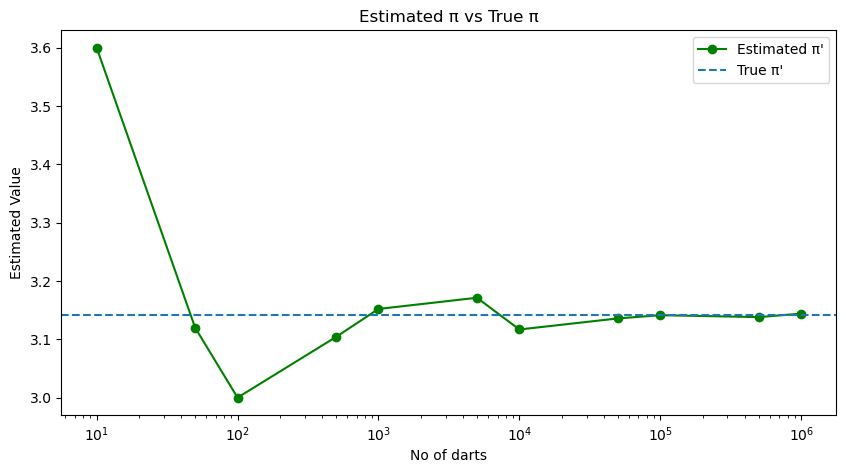

In [9]:
import random
import matplotlib.pyplot as plt
import math

nval= [10,50,100,500,1000,5000,10000,50000,100000,500000, 1000000]
estimate=[]

for n in nval:
    in_c=0
    for _ in range (n):
        x=random.uniform(-1,1)
        y=random.uniform(-1,1)
        if x**2+y**2<=1:
            in_c+=1
    estimate.append(4*(in_c/n))
    print(f"{n} \t\t {4*(in_c/n)}")

plt.figure(figsize=(10,5))
plt.plot(nval,estimate, marker="o", color='green', label= "Estimated π'")
plt.axhline(y=math.pi, linestyle="--", label= "True π'")
plt.title("Estimated π vs True π")
plt.xlabel("No of darts")
plt.ylabel("Estimated Value")
plt.legend()
plt.xscale('log')
plt.show()

**RESULT**
At n = 10, the estimate is wild — sometimes 2.8, sometimes 3.6. At n = 100, it
tightens. By n = 10,000, it's usually within 0.01 of the true value. At n = 1,000,000,
we get 3-4 stable decimal places.

The convergence is real but slow. The law is: to halve the error, you need 4 times
more darts or to gain one decimal digit, you need 100 times more.

Monte Carlo never gives the exact answer. It gives a confidence interval that
shrinks as $\frac{1}{\sqrt n}$.


## 5. Distribution of the Estimated Datas:
---
A single estimate of π from 100,000 darts is just one draw from a probability
distribution. We want to find the nature of the distribution.

We first do 100 times the 1000 darts run and check the histogram of the datas.

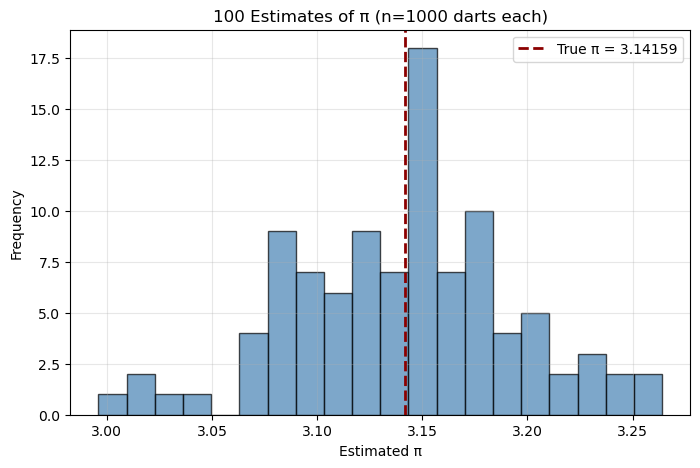

In [20]:
import random
import matplotlib.pyplot as plt
import math
x=y=0

n=1000

pi_val=[]

for _ in range (100):
    in_x=0
    for i in range(n):
        x= random.uniform(-1,1)
        y= random.uniform(-1,1)
        dist= ((x*x)+(y*y))**0.5
        if dist<=1:
            in_x+=1
            
    pi_val.append((4*in_x/n))

plt.figure(figsize=(8, 5))
plt.hist(pi_val, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=math.pi, color='darkred', linestyle='--', linewidth=2, label=f'True π = {math.pi:.5f}')
plt.xlabel('Estimated π')
plt.ylabel('Frequency')
plt.title('100 Estimates of π (n=1000 darts each)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**RESULT:**

This forms a histogram with jagged peaks and it becomes almost inconclusive as this sample size is small, we need to increase the sample size to understand the underlying concepts of this data, and for that we need to run with a larger number of darts larger number of times.


Now we make another experiment with 10000 darts and running 1000 times (I tried running 100,000 darts for 100,000 times but it failed miserably my PC cant handle so much for now lets do small) Just changing the values of the required areas we get:


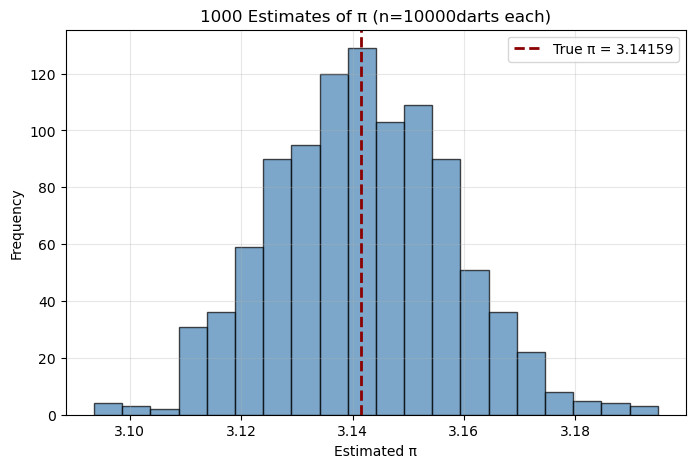

In [2]:
import random
import matplotlib.pyplot as plt
import math
x=y=0

n=10000

pi_val=[]

for _ in range (1000):
    in_x=0
    for i in range(n):
        x= random.uniform(-1,1)
        y= random.uniform(-1,1)
        dist= ((x*x)+(y*y))**0.5
        if dist<=1:
            in_x+=1
            
    pi_val.append((4*in_x/n))

plt.figure(figsize=(8, 5))
plt.hist(pi_val, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=math.pi, color='darkred', linestyle='--', linewidth=2, label=f'True π = {math.pi:.5f}')
plt.xlabel('Estimated π')
plt.ylabel('Frequency')
plt.title(f'1000 Estimates of π (n={n}darts each)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**RESULT:**

We get a smooth bell curve which emerges, centered on the true value of $\pi$. Most runs land very close. A few wander further away, producing estimates that are slightly too high or too low. But the spread is narrow and the vast majority fall within $\pm 0.04$ of the true value.

Monte Carlo doesn't give us a single answer, it gives us a distribution. The more runs we average over, the clearer that distribution becomes, and at its peak, the most probable value sits π.

## 6. Error Estimation:
---

Theory predicts that Monte Carlo error decreases as $\frac {1}{\sqrt n}$. We test this directly.

For each n from 10 to 100,000, we run the experiment 50 times and compute the average absolute error. We plot this error against $\frac {1}{\sqrt n}$.

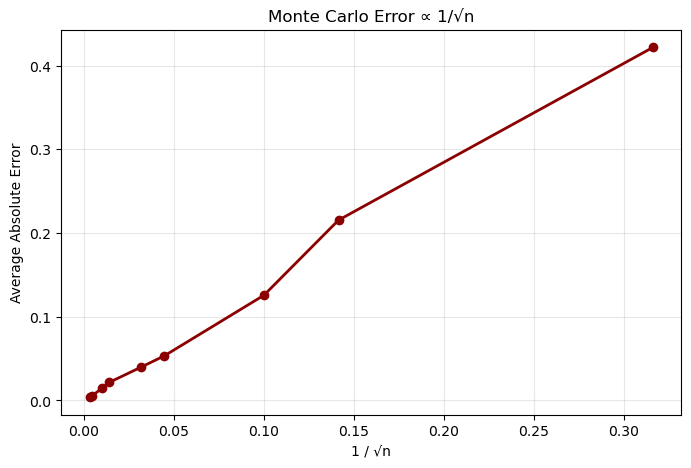

In [6]:
n_val = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
avg_err = []
runs = 50

for n in n_val:
    err = []
    for _ in range(runs):
        inside = 0
        for _ in range(n):
            x = random.uniform(-1, 1)
            y = random.uniform(-1, 1)
            if x**2 + y**2 <= 1:
                inside += 1
        pi_est = 4 * inside / n
        err.append(abs(pi_est - math.pi))
    avg_err.append(sum(err) / runs)

inv_sqrt_n = [1 / math.sqrt(n) for n in n_val]

plt.figure(figsize=(8, 5))
plt.plot(inv_sqrt_n, avg_err, marker='o', color='darkred', linewidth=2)
plt.xlabel('1 / √n')
plt.ylabel('Average Absolute Error')
plt.title('Monte Carlo Error ∝ 1/√n')
plt.grid(True, alpha=0.3)
plt.show()

On a linear plot of error vs $\frac {1}{\sqrt n}$, the points fall on a straight line through the origin. This confirms that as theory predicts:
>error is proportional to $\frac {1}{\sqrt n}$

This is both the strength and weakness of Monte Carlo:
- Strength: Convergence is guaranteed, no matter how complex the problem
- Weakness: Convergence is slow. 100× more computation for 10 times better accuracy

Thus,
1. For low-dimensional problems with smooth functions, other methods are far superior.
2. For high-dimensional problems or systems with complex boundaries — Monte Carlo is often the only method that works at all.

## Conclusion:
---

Comparing this method to other methods to calculate the value of $\pi$.

| Method | Example | Correct Digits (with ~10⁶ operations) | Notes |
|--------|---------|--------------------------------------|-------|
| **Archimedes' method** | Polygons with increasing sides | ~6 | 250 BC. Still works. |
| **Leibniz series** | $1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \cdots = \frac{\pi}{4}$ | ~6 | Beautiful. Converges slowly. |
| **Machin's formula** | $\frac{\pi}{4} = 4\arctan\frac{1}{5} - \arctan\frac{1}{239}$ | ~100 | Converges rapidly. Pre-computer era favorite. |
| **Ramanujan's series** | $\frac{1}{\pi} = \frac{2\sqrt{2}}{9801} \sum_{k=0}^{\infty} \frac{(4k)!(1103+26390k)}{(k!)^4 396^{4k}}$ | ~8 per term | Each term adds ~8 correct digits. |
| **Chudnovsky algorithm** | Variant of Ramanujan | ~14 per term | Used for world record calculations. |
| **Monte Carlo** | Random darts on a square | **~3** | Terrible for $\pi$. Great for learning. |

From here we can say, Monte Carlo is a terrible way to estimate π. $\frac{22}{7}$ is faster. Any series formula is better than this.

So why did we spend this time?

Because $\pi$ is the benchmark, not the goal. When we can estimate $\pi$ with Monte Carlo, we understand the method. We can then apply it to problems where no formula exists:
- Light intensity across a complex chip pattern (lithography)
- Neutron diffusion in a nuclear reactor
- Climate model uncertainty

Monte Carlo is slow. It's noisy. It never gives an exact answer. But when the problem is too complex for any other approach it works always. 

The core reason of us making the model to simulate $\pi$ was just to answer the question whether can we get a something which just some random events on a dart board. Without even using complex formulas we brought out $\pi$ to a very low accuracy but what we can use in our day to day life, using Monte Carlo Method helps mostly when we don't know any formulas related to it, its just hitting a wall everytime we fail and as the number of people hitting a wall increases we start to figure out the answer to the question that we wanted. 

---
